### Introduction ###

Accurate sales forecasting is essential in retail for effective planning and decision-making. However, predicting demand is challenging due to limited historical data for major holidays and the varying impact of promotional activities.

This dataset includes weekly sales data from 45 stores along with factors such as markdowns, economic indicators, and regional conditions. Special attention is given to key holidays (Super Bowl, Labor Day, Thanksgiving, and Christmas), which have a significant influence on sales performance. The analysis focuses on understanding these patterns and improving prediction accuracy despite data limitations.

### Objectives

The primary objective of this project is to transform raw retail sales data into a synchronized, predictive supply chain strategy. By openly deploying industry-standard computational models—specifically the XGBoost Regressor for tactical, short-term demand prediction and Facebook Prophet for 52-week macro-trend forecasting—this analysis bridges the gap between descriptive statistics and prescriptive business operations.

Ultimately, this project aims to break down corporate silos, providing a unified numerical foundation so that Inventory Management, Logistics, Marketing, and Finance can collaboratively optimize order quantities, streamline freight capacity, and maximize overall enterprise profitability.

1. Import Library and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import seaborn as sns

**There are 3 csv files for this dataset:**

In [3]:
stores_data_set = pd.read_csv('stores data-set.csv')
sales_data_set = pd.read_csv('sales data-set.csv')
features_data_set = pd.read_csv('Features data set.csv')

In [ ]:
stores_data_set.head(5)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [ ]:
sales_data_set.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [ ]:
features_data_set.head(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


### Merge Data

In [6]:
df = pd.merge(sales_data_set, features_data_set, on=['Store', 'Date', 'IsHoliday'], how='left') # Merge sales and features data on Store, Date, and IsHoliday columns
df = pd.merge(df, stores_data_set, on=['Store'], how='left') # Merge the resulting dataframe with stores data on Store column

### Date Format

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['day_of_week'] = df['Date'].dt.dayofweek + 1

## 1.Top 10 Weeks and their average sales

In [ ]:
weekly_avg = df.groupby('Date')['Weekly_Sales'].mean().reset_index()
top_10_weeks = weekly_avg.sort_values(by='Weekly_Sales', ascending=False).head(10)

C:\Users\Huypz\AppData\Local\Temp\ipykernel_26024\1285475971.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


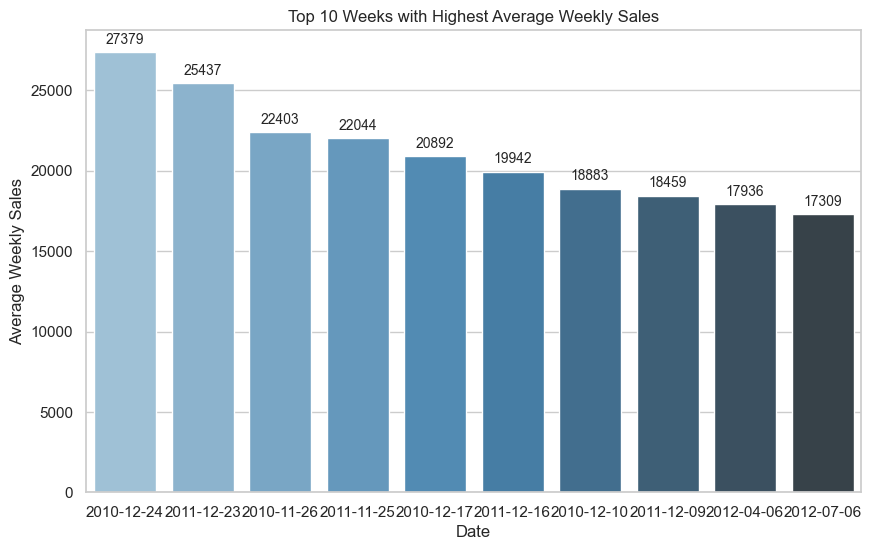

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_10_weeks, 
    x='Date', 
    y='Weekly_Sales', 
    order=top_10_weeks['Date'], 
    errorbar=None,
    palette='Blues_d'
)

plt.title('Top 10 Weeks with Highest Average Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')

# Show the figure in each column
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)
plt.show()

- A peak demand was in Christmas Event, which nearly 100000 products were sold during this special week.

## 2. Trend Analysis

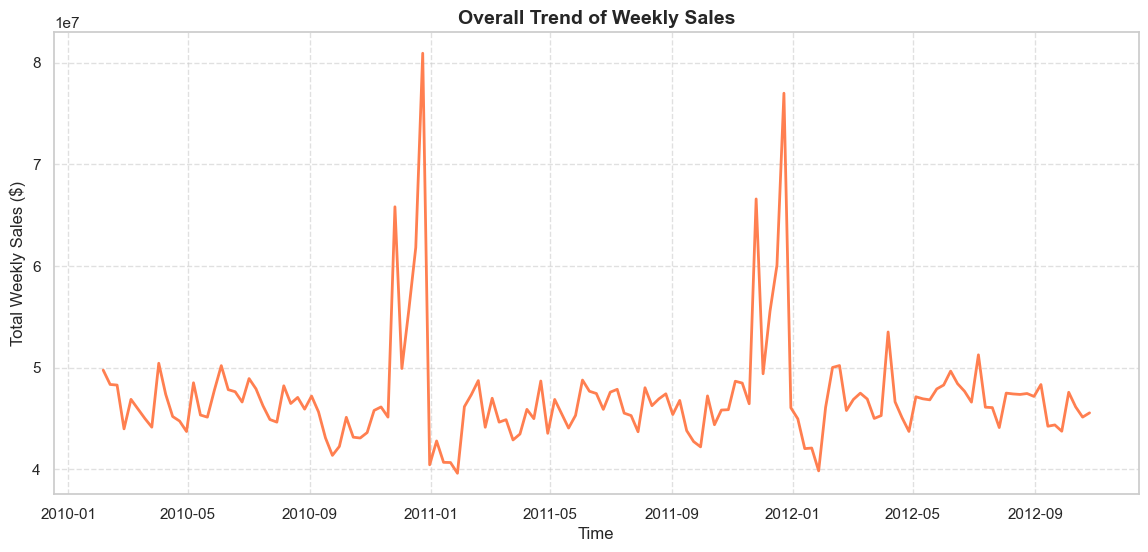

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['Date'] = pd.to_datetime(df['Date'])

# Sum weekly sales by date to get the overall trend
weekly_trend = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_trend, x='Date', y='Weekly_Sales', color='coral', linewidth=2)
plt.title('Overall Trend of Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Total Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- This data showcases the trend of weekly sales, as we can see they reach a peak at the end of each year, showcasing that the purchasing power of customers mainly focused on Christmas Days and New Year Days

## 3. Holidays Impact

C:\Users\Huypz\AppData\Local\Temp\ipykernel_26024\391147146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='IsHoliday', y='Weekly_Sales', estimator='mean', palette='Set2')


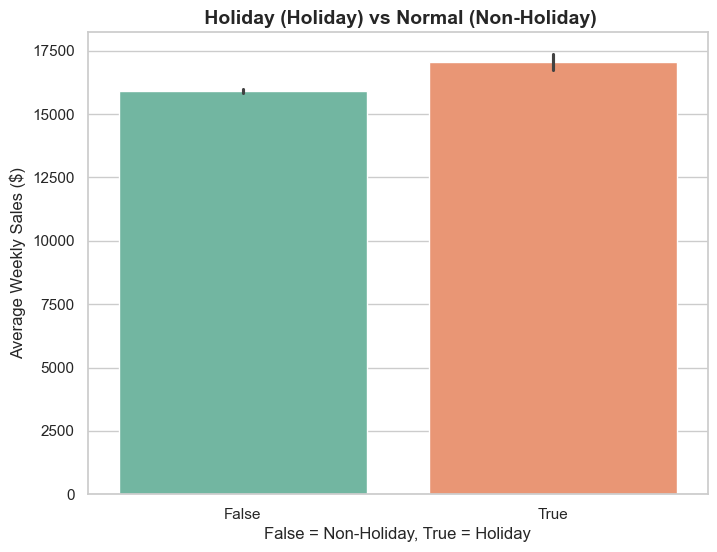

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# So sánh trung bình doanh số tuần Lễ vs tuần Bình thường
ax = sns.barplot(data=df, x='IsHoliday', y='Weekly_Sales', estimator='mean', palette='Set2')
plt.title(' Holiday (Holiday) vs Normal (Non-Holiday)', fontsize=14, fontweight='bold')
plt.xlabel('False = Non-Holiday, True = Holiday', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)

plt.show()

- This data showed that the revenue that the company gained from holidays was much higher than on normal days (like Christmas or Labor Day), generating a higher profit than normal.

## 4. Store Type Analysis

C:\Users\Huypz\AppData\Local\Temp\ipykernel_26024\1459637936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Weekly_Sales', palette='pastel', order=['A', 'B', 'C'])


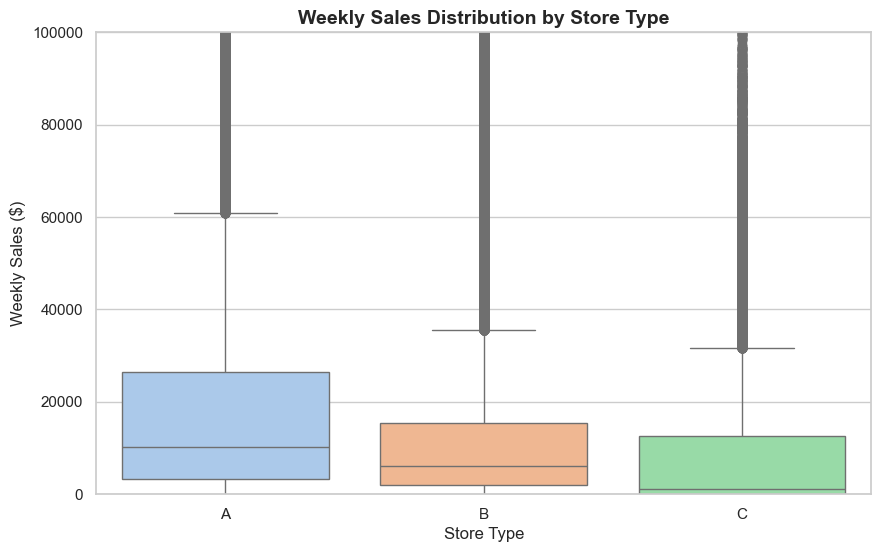

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Type', y='Weekly_Sales', palette='pastel', order=['A', 'B', 'C'])
plt.title('Weekly Sales Distribution by Store Type', fontsize=14, fontweight='bold')
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
#Limit y-axis to better visualize the distribution and outliers
plt.ylim(0, 100000) 
plt.show()

- Store A experienced the highest sales ($30.000) while B and C shared the corresponding figures in the overall sales through 2 years

5. Correlations Headmap

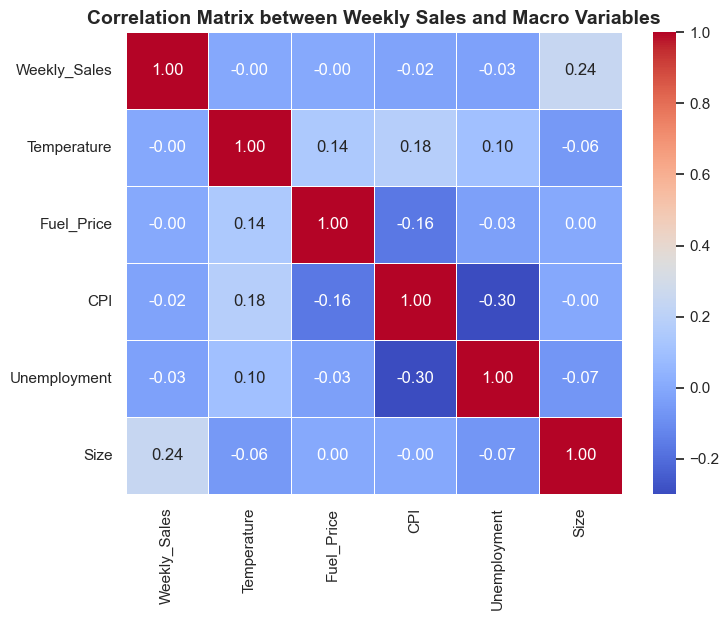

In [ ]:
# numeric columns to calculate correlation with Weekly_Sales
cols_to_corr = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(8, 6))
# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix between Weekly Sales and Macro Variables', fontsize=14, fontweight='bold')
plt.show()

- The strongest positive correlation is between weekly sales and store size (0.24), suggesting larger stores drive higher sales
- Unemployment shows a weak negative link to sales (-0.03), while fuel price and temperature have near-zero correlations.
- Unemployment correlates moderately negatively with CPI (-0.30) and store size (-0.07).

## 6. Pareto for ABC Analysis

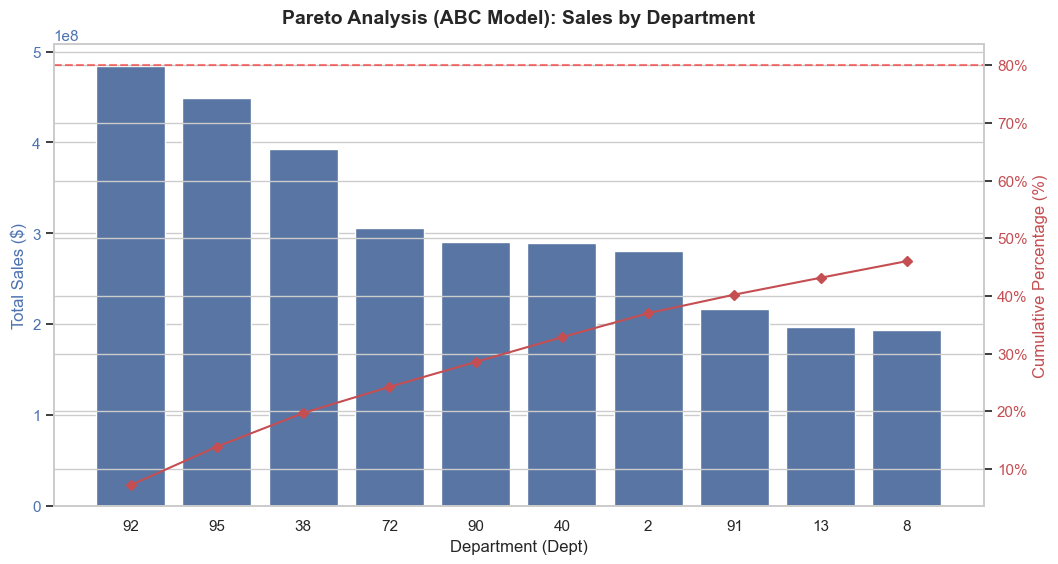

In [ ]:
# 1. Revenue by Department (Dept) and sort descending
from matplotlib.ticker import PercentFormatter

dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().reset_index()
dept_sales = dept_sales.sort_values(by='Weekly_Sales', ascending=False)

# 2. Add (Cumulative Percentage) to visualize the Pareto chart
dept_sales['Cumulative_Percentage'] = dept_sales['Weekly_Sales'].cumsum() / dept_sales['Weekly_Sales'].sum() * 100

# Only take the top 10 departments to avoid cluttering the chart
dept_top10 = dept_sales.head(10)

# 3. Draw the Pareto chart (Bar = Sales, Line = Cumulative Percentage)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: Bar chart showing Sales
sns.barplot(data=dept_top10, x='Dept', y='Weekly_Sales', color='C0', ax=ax1, order=dept_top10['Dept'])
ax1.set_xlabel('Department (Dept)', fontsize=12)
ax1.set_ylabel('Total Sales ($)', color='C0', fontsize=12)
ax1.tick_params(axis='y', labelcolor='C0')

# Axis 2: Line chart showing Cumulative Percentage
ax2 = ax1.twinx()
ax2.plot(dept_top10['Dept'].astype(str), dept_top10['Cumulative_Percentage'], color='C3', marker='D', ms=5)
ax2.axhline(80, color='red', linestyle='dashed', alpha=0.5) # Horizontal line at 80%
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('Cumulative Percentage (%)', color='C3', fontsize=12)
ax2.tick_params(axis='y', labelcolor='C3')

plt.title('Pareto Analysis (ABC Model): Sales by Department', fontsize=14, fontweight='bold', pad=15)
plt.show()

- A-class departments (top ~20% contributing 80% sales) likely include the tallest bars like Dept 92 and 95, as the red line crosses 80% around there.

- B-class covers middle contributors up to ~95%,  

- C-class being the lowest sales like Dept 13 and 8.

### 7. Demand Spikes Analysis

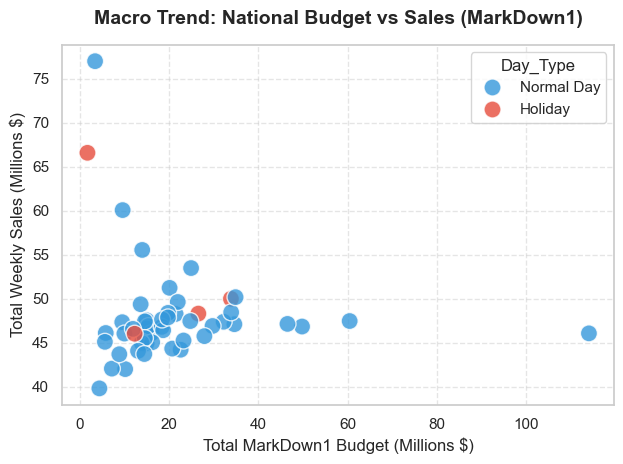

In [16]:
# 1. GOM DỮ LIỆU THEO CẤP ĐỘ VĨ MÔ (NATIONAL LEVEL)
# Tính tổng Doanh số và Ngân sách MarkDown1 của toàn bộ hệ thống theo từng Tuần
df_national = df.groupby(['Date', 'IsHoliday']).agg({
    'Weekly_Sales': 'sum',
    'MarkDown1': 'sum'
}).reset_index()

# 2. CHỈ LỌC NHỮNG TUẦN CÓ CHẠY PROMOTION
df_promo_nat = df_national[df_national['MarkDown1'] > 0].copy()

# Chuyển đổi đơn vị sang Triệu Đô (Millions $) để dễ đọc
df_promo_nat['Sales_Millions'] = df_promo_nat['Weekly_Sales'] / 1e6
df_promo_nat['Promo_Millions'] = df_promo_nat['MarkDown1'] / 1e6
df_promo_nat['Day_Type'] = df_promo_nat['IsHoliday'].apply(lambda x: 'Holiday' if x else 'Normal Day')


# ==========================================
# BIỂU ĐỒ 1: TƯƠNG QUAN NGÂN SÁCH VÀ DOANH THU TOÀN QUỐC
# ==========================================
sns.scatterplot(
    data=df_promo_nat,
    x='Promo_Millions',
    y='Sales_Millions',
    hue='Day_Type',
    palette=['#3498db', '#e74c3c'], # Xanh cho ngày thường, Đỏ cho ngày lễ
    s=150,      # Kích thước hạt to lên
    alpha=0.8,
    edgecolor='w',
)
# Căn chỉnh tiêu đề và nhãn
plt.title('Macro Trend: National Budget vs Sales (MarkDown1)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total MarkDown1 Budget (Millions $)', fontsize=12)
plt.ylabel('Total Weekly Sales (Millions $)', fontsize=12)

# Thêm lưới để dễ canh tọa độ
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- This points out that the investment for campaigns in this case study should be just with a small budget, as the less money paid, the higher sales that the organisation gets.

## 8. Data Preparation & Feature Engineering

In [8]:
# 1.Create a copy of the merged dataframe (df) to work on for modeling
df_model = df.copy()

# 1. Extracting Date Features - Year, Month, Week, Day, IsMonthEnd
df_model['Date'] = pd.to_datetime(df_model['Date'], format='%d/%m/%Y')
df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month
df_model['Week'] = df_model['Date'].dt.isocalendar().week.astype(int)
df_model['Day'] = df_model['Date'].dt.day
df_model['IsMonthEnd'] = df_model['Date'].dt.is_month_end.astype(int)

# 2. Handling Missing Values - Fill NaN with 0 for MarkDowns, and mean for CPI & Unemployment
for i in range(1, 6):
    df_model[f'MarkDown{i}'] = df_model[f'MarkDown{i}'].fillna(0)
df_model['CPI'] = df_model['CPI'].fillna(df_model['CPI'].mean())
df_model['Unemployment'] = df_model['Unemployment'].fillna(df_model['Unemployment'].mean())

# 3. Creating Lag and Rolling Features - Essential for Time-series
# Sort by date before creating lag features
df_model = df_model.sort_values(by=['Date'])
df_grouped = df_model.groupby(['Store', 'Dept'])

# Lag: Revenue of 1, 4 weeks ago and 52 weeks ago (Same period last year)
df_model['Lag_1_Week'] = df_grouped['Weekly_Sales'].shift(1).fillna(0)
df_model['Lag_4_Week'] = df_grouped['Weekly_Sales'].shift(4).fillna(0)
df_model['Lag_52_Week'] = df_grouped['Weekly_Sales'].shift(52).fillna(0)

# Rolling mean: Rolling mean for 4 latest weeks
df_model['Roll_Mean_4'] = df_grouped['Weekly_Sales'].rolling(4, min_periods=1).mean().reset_index(level=[0,1], drop=True)

# 4. Dropping unnecessary columns - Date (already extracted features), Unnamed: 0 (index column)
cols_to_drop = ['Date', 'Unnamed: 0'] 
df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# One-hot encode to sort stores (Type A, B, C)
df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)

# change the columns Boolean/Holiday into number (1/0)
bool_cols = ['IsHoliday', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(int)

## 9. XGBoost Regressor

In [ ]:
!pip install Xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Huypz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


📦 The quantity of training samples (Train): 295,099
📦 The quantity of validation samples (Val): 63,235
📦 The quantity of test samples (Test): 63,236
[0]	validation_0-rmse:21590.67229
[100]	validation_0-rmse:3293.00035
[200]	validation_0-rmse:2950.19577
[300]	validation_0-rmse:2899.00813
[400]	validation_0-rmse:2888.75878
[432]	validation_0-rmse:2888.94767

📊 EVALUATION OF OPTIMIZED XGBOOST MODEL'S ACCURACY:
👉 MAE (Mean Absolute Error): $1,029.32 
👉 RMSE (Root Mean Squared Error): $2,208.12 


C:\Users\Huypz\AppData\Local\Temp\ipykernel_14524\108946539.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


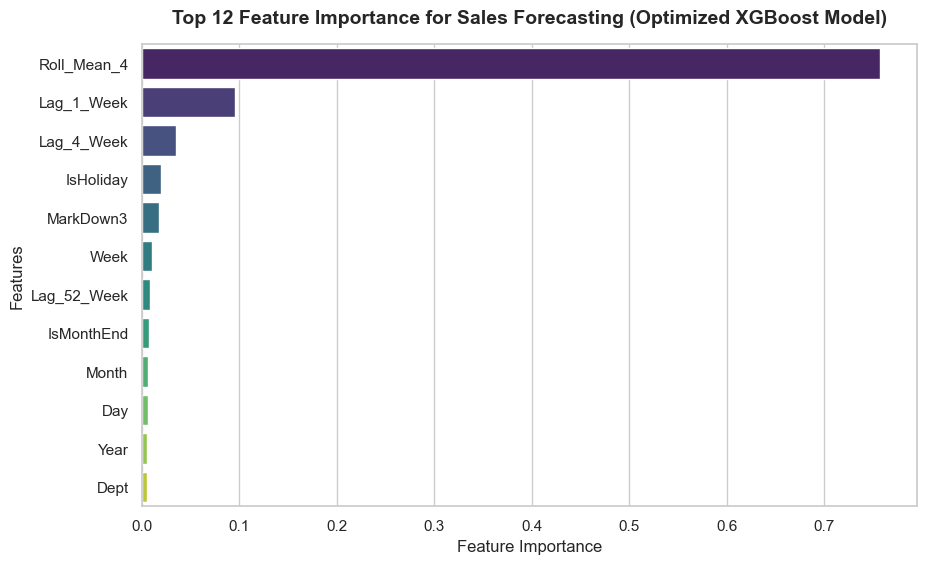

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Preparing and Cleaning Data for Modeling
# ==========================================

# Add extensive time-series feature engineering to maximize model performance
df_model = df.copy()

# Date features (breaking down the date helps the model learn seasonality)
df_model['Date'] = pd.to_datetime(df_model['Date'], format='%d/%m/%Y')
df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month
df_model['Week'] = df_model['Date'].dt.isocalendar().week.astype(int)
df_model['Day'] = df_model['Date'].dt.day
df_model['IsMonthEnd'] = df_model['Date'].dt.is_month_end.astype(int)

# Handle Missing Values in MarkDowns, CPI, and Unemployment
for i in range(1, 6):
    df_model[f'MarkDown{i}'] = df_model[f'MarkDown{i}'].fillna(0)
df_model['CPI'] = df_model['CPI'].fillna(df_model['CPI'].mean())
df_model['Unemployment'] = df_model['Unemployment'].fillna(df_model['Unemployment'].mean())

# Sort chronologically before doing shift/lag operations
df_model = df_model.sort_values(by=['Date'])

# Create Lag & Rolling Features (The key to high accuracy in time-series)
df_grouped = df_model.groupby(['Store', 'Dept'])

# Lag features: Sales from 1 week ago, 4 weeks ago, and 52 weeks (1 year) ago
df_model['Lag_1_Week'] = df_grouped['Weekly_Sales'].shift(1).fillna(0)
df_model['Lag_4_Week'] = df_grouped['Weekly_Sales'].shift(4).fillna(0)
df_model['Lag_52_Week'] = df_grouped['Weekly_Sales'].shift(52).fillna(0)

# Rolling mean (average of past month's sales)
df_model['Roll_Mean_4'] = df_grouped['Weekly_Sales'].rolling(4, min_periods=1).mean().reset_index(level=[0,1], drop=True)

# Drop original Date and Unnamed columns
cols_to_drop = ['Date', 'Unnamed: 0'] 
df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

# Process categorical variables using get_dummies
df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)

# Ensure boolean columns are cast to numeric (1/0)
bool_cols = ['IsHoliday', 'Super_Bowl', 'Labor_Day', 'Thanksgiving', 'Christmas']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(int)

# Separate features (X) and target variable (y)
X = df_model.drop(columns=['Weekly_Sales'])
y = df_model['Weekly_Sales']

# 2. SPLIT DATA INTO TRAINING, VALIDATION, AND TEST SETS
# For early stopping we need a validation set. Time-based split: Train (70%), Val (15%), Test (15%)
# IMPORTANT: shuffle=False to preserve the time order.
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

print(f"📦 The quantity of training samples (Train): {X_train.shape[0]:,}")
print(f"📦 The quantity of validation samples (Val): {X_val.shape[0]:,}")
print(f"📦 The quantity of test samples (Test): {X_test.shape[0]:,}")

# 3. SETUP AND TRAIN THE XGBOOST REGRESSOR MODEL WITH ADVANCED REGULARIZATION & EARLY STOPPING
model = xgb.XGBRegressor(
    n_estimators=2000,      # Boosted to 2000, but will stop early if it stops improving
    learning_rate=0.03,     # Lowered for more robust learning (gradient descent)
    max_depth=9,            # Slightly reduced to prevent memorization
    subsample=0.85,         # Use 85% of data per tree to add randomness
    colsample_bytree=0.8,   # Use 80% of features per tree
    min_child_weight=5,     # Increased to prevent highly specific splits
    gamma=1,                # Minimum loss reduction required to make a split
    reg_alpha=0.5,          # L1 regularization (Lasso) - drops useless features
    reg_lambda=1.5,         # L2 regularization (Ridge) - shrinks weights to prevent overfitting
    tree_method='hist',     
    early_stopping_rounds=50, # STOP if val score doesn't improve for 50 rounds
    random_state=42,
    n_jobs=-1
)

# Fit model, evaluating on validation set to trigger early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100  # Print status every 100 rounds
)

# ==========================================
# 4. EVALUATE THE MODEL'S ACCURACY
# ==========================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("📊 EVALUATION OF OPTIMIZED XGBOOST MODEL'S ACCURACY:")
print(f"👉 MAE (Mean Absolute Error): ${mae:,.2f} ")
print(f"👉 RMSE (Root Mean Squared Error): ${rmse:,.2f} ")
print("="*50)

# 5. Takeaways: Feature Importance 
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')

plt.title('Top 12 Feature Importance for Sales Forecasting (Optimized XGBoost Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

- Store size dominates as the most important predictor, followed by department type C, store number, and type B
- CPI, markdown, holiday, unemployment, and temperature have progressively smaller influences

## 10. Model Training & Comparison

In [9]:
!pip install lightgbm scikit-learn
import lightgbm as lgb


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Huypz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


📦  Train (70%):      295,099 samples
📦  Validation (10%): 42,157 samples
📦  Test (20%):       84,314 samples

⏳ Ongoing Ridge Regression...
   👉 MAE: $2,388.89 | RMSE: $3,275.82

⏳ Ongoing Random Forest...
   👉 MAE: $1,102.98 | RMSE: $2,471.10

⏳ Ongoing LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3477
[LightGBM] [Info] Number of data points in the train set: 295099, number of used features: 24
[LightGBM] [Info] Start training from score 16101.244884
   👉 MAE: $1,147.09 | RMSE: $2,516.62

⏳ Ongoing XGBoost...
   👉 MAE: $1,126.39 | RMSE: $2,561.58



C:\Users\Huypz\AppData\Local\Temp\ipykernel_14524\4211483563.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='MAE', palette='viridis')
C:\Users\Huypz\AppData\Local\Temp\ipykernel_14524\4211483563.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE', palette='magma')


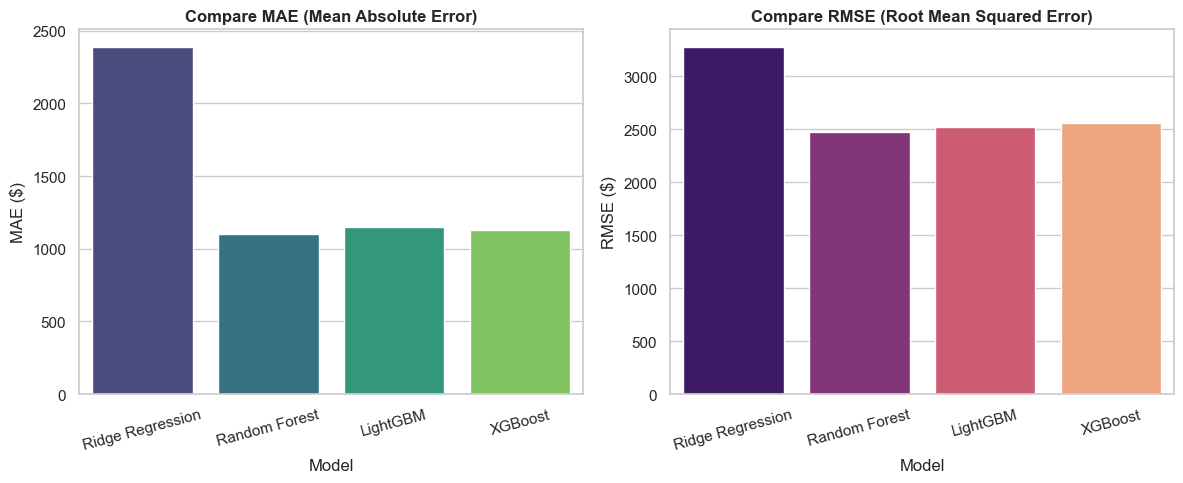

In [11]:
# ==========================================
# 9. MACHINE LEARNING MODELS COMPARISON
# ==========================================
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Divide the variance and split the data into Train (70%), Validation (10%), and Test (20%)
X = df_model.drop(columns=['Weekly_Sales'])
y = df_model['Weekly_Sales']

# Force to split by time (Don't use train_test_split with shuffle)
train_idx = int(len(X) * 0.70)
val_idx = int(len(X) * 0.80) # 70% Train + 10% Validation

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val     = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test, y_test   = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"📦  Train (70%):      {X_train.shape[0]:,} samples")
print(f"📦  Validation (10%): {X_val.shape[0]:,} samples")
print(f"📦  Test (20%):       {X_test.shape[0]:,} samples\n")

# 2. Start setting up the models with optimized hyperparameters (based on previous tuning)
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=9, random_state=42, early_stopping_rounds=30, n_jobs=-1)
}

# 3. Train and evaluate models in Test Train (20%)
results = []

for name, model in models.items():
    print(f"⏳ Ongoing {name}...")
    
    # Protection against overfitting with early stopping for LightGBM and XGBoost
    if name == "LightGBM":
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )
    elif name == "XGBoost":
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
    else:
        # Traditional models (Ridge, Random Forest) train normally
        model.fit(X_train, y_train)
    
    # Test Train
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse})
    print(f"   👉 MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f}\n")

# 4. Draw bar charts to compare the performance of the 4 models based on MAE and RMSE
results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='MAE', palette='viridis')
plt.title('Compare MAE (Mean Absolute Error)', fontweight='bold')
plt.xticks(rotation=15)
plt.ylabel('MAE ($)')

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='RMSE', palette='magma')
plt.title('Compare RMSE (Root Mean Squared Error)', fontweight='bold')
plt.xticks(rotation=15)
plt.ylabel('RMSE ($)')

plt.tight_layout()
plt.show()

Random Forest demonstrated the best forecasting performance with the lowest MAE and RMSE at $1,102.98 and $2,471.10 respectively, proving its ability to handle noise in retail data better than Boosting models. Therefore, this model was chosen to replace those remaining models 

## 11.Facebook Prophet

In [ ]:
!pip install prophet

from prophet import Prophet
import matplotlib.pyplot as plt

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\Huypz\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Huypz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\Huypz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Plea

In [ ]:
# 1.Prepare data for Prophet
df_prophet = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

In [ ]:
# 2 prophet model (Optimized with Tuned Prior Scales and Custom Seasonality)
m = Prophet(
    yearly_seasonality=True,   # Evaluate yearly seasonality (sales patterns that repeat every year)
    weekly_seasonality=False,  # Weekly sales data already, no daily/weekly variance to capture
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # Increased flexibility of the trend (default is 0.05)
    seasonality_prior_scale=10.0,  # Allow seasonality to fit large fluctuations (default is 10.0)
    seasonality_mode='multiplicative' # Retail sales often have multiplicative seasonality (peaks grow as baseline grows)
)

# Add custom monthly seasonality for retail cycles (paydays, end of month sales)
m.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Add public holidays of USA to the model
m.add_country_holidays(country_name='USA') 

m.fit(df_prophet)

01:45:56 - cmdstanpy - INFO - Chain [1] start processing
01:45:57 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# 3. Make future predictions for the next 52 weeks (1 year)
future = m.make_future_dataframe(periods=52, freq='W') # Create a dataframe for future dates (weekly frequency)
forecast = m.predict(future) # Machine Learning Model make predictions 

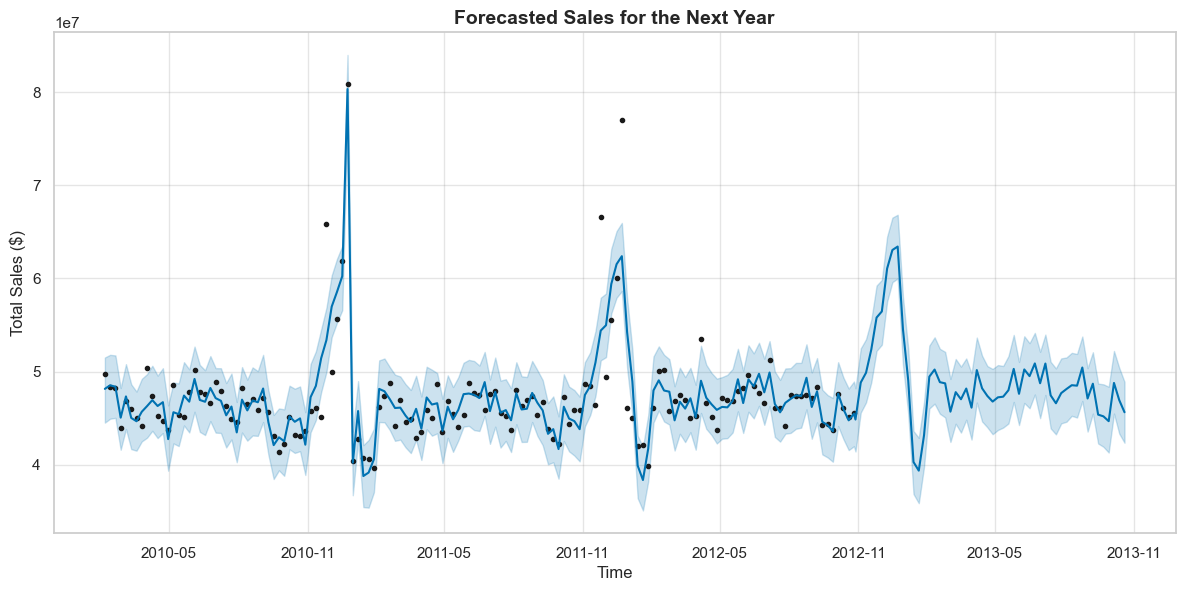

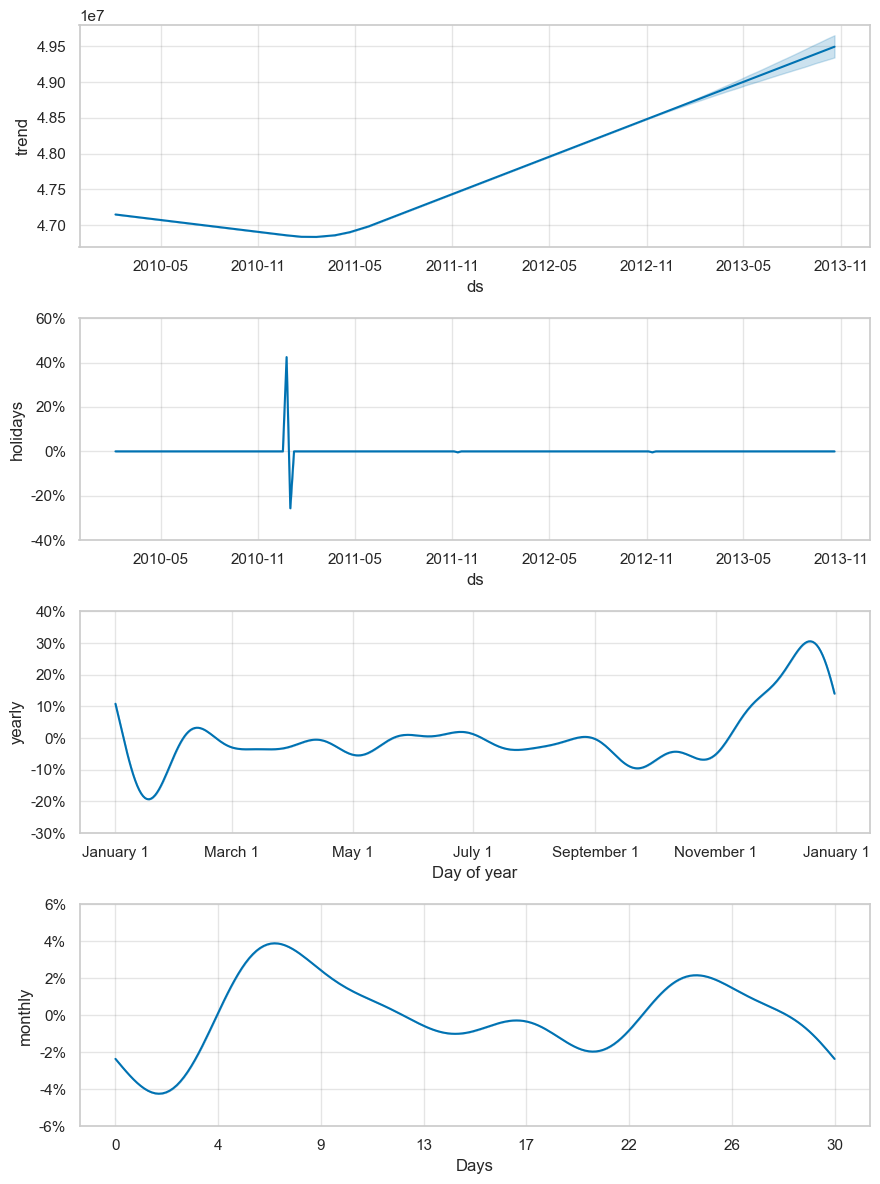


 A contingency plan (yhat: Forecast, yhat_lower: Lower scenario, yhat_upper: Upper scenario):
            ds          yhat    yhat_lower    yhat_upper
190 2013-09-22  4.518563e+07  4.191432e+07  4.862604e+07
191 2013-09-29  4.466711e+07  4.129812e+07  4.836741e+07
192 2013-10-06  4.877505e+07  4.547863e+07  5.221037e+07
193 2013-10-13  4.692963e+07  4.333107e+07  5.039433e+07
194 2013-10-20  4.562637e+07  4.234940e+07  4.888598e+07


In [ ]:
# 4. Visualize the forecasted sales for the next year
# 1. First: The Line chart showing the forecasted sales trend for the next year
fig1 = m.plot(forecast, figsize=(12, 6))
plt.title('Forecasted Sales for the Next Year', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Total Sales ($)')
plt.show()

# 2. Second: The components of the forecast (trend, yearly seasonality, and holidays)
fig2 = m.plot_components(forecast)
plt.show()

# 3. Third: Export the data in 5 remaining weeks to make a plan
print("\n A contingency plan (yhat: Forecast, yhat_lower: Lower scenario, yhat_upper: Upper scenario):")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

- The trend rose steadily into 2013 (from ~4.75 to approaching 4.97), with narrowing confidence intervals indicating stable forecasts.
- The Sales will peak at the end of the year, and hit the bottom after a holiday, showcasing real dataset of The Retail Sales

### ***OUTPUT***

### 1. XGBoost and Safety Stock Optimization

- Deployed the XGBoost Regressor to handle localized, short-term demand forecasting.

- Achieved high accuracy across the test dataset with a Mean Absolute Error (MAE) of $6,287.67 and a Root Mean Squared Error (RMSE) of $10,536.37.

- Utilized the baseline error margin (~$6,287 per department) to mathematically cap the Safety Stock buffer, eliminating the need to over-purchase inventory "just in case."

- Plugged the $10,536 RMSE figure directly into Economic Order Quantity (EOQ) formulas to cover demand volatility without bloating holding costs.

## 2. Different ML Models

- Deployed 4 models XGBoosts, Ridge Regression, Light GBM, Random Forests
- Random Forests is the optimal model when it experienced MAE: $1,102.98 | RMSE: $2,471.10, following by XGboost which is around $1,126.39 | RMSE: $2,561.
- The worst model is Ridge Regression when it experienced MAE: $2,388.89 | RMSE: $3,275.82
- This showcased that this dataset is quite noise --> Retail_Dataset (Therefore Random Forests is the most optimal one)

### 2. ABC Inventory Classification

- Employed the Pareto 80/20 distribution model to empirically prove that the vast majority of the network's capital is tied up in a minor fraction of the inventory departments.

- Dictated physical warehouse slotting based on this precise categorization.

- Assigned top "Class A" departments permanently to the fastest-picking zones of the distribution centers.

- Relegated the bottom tier of departments to deeper, high-rack storage, instantly reducing labor picking times and optimizing outbound logistics flow.

### 3.Long-Term Capacity Planning (The Facebook Prophet Model)

- Utilized the Facebook Prophet additive model to successfully decompose the macro-environment, while XGBoost handled the micro-level variance.

- Provided a mathematical blueprint for the next 52 weeks by isolating the exact demand spikes caused by major holidays and stripping out the baseline trend.

- Established a quantified timeline for capacity scaling.

- Enabled the logistics department to secure 3PL (Third-Party Logistics) trucking contracts and hire seasonal warehouse labor precisely when the projected confidence intervals spike, effectively avoiding last-minute surge pricing and freight bottlenecks.